# 03 · Parameter sweeps

Use the experiment runner to explore multiple configurations automatically.

In [18]:
# Core configuration and grid definitions
from src.config import GridSpec, SweepConfig

# Numerical operators and discretisation schemes
from src.operators import FiniteDifference

# Load (RHS) definitions
from src.loads import PointSource, PlaneWaveSource, RandomSource

# Experiment orchestration
from src.experiments import run_experiment

# Visualisation utilities
from src.visualisation import plot_residuals

from src.solvers import GMRESOptions 

import matplotlib.pyplot as plt
import numpy as np


## Define the sweep parameters

We specify:
- **Grids** via `GridSpec(dims, shape, lengths)`;
- **Wavenumbers** as a list of floats;
- **Loads (RHS)**: `PointSource`, `PlaneWaveSource`, `RandomSource`;
- **Discretisations**: here `FiniteDifference()` with defaults.

**Randomness options**
- `PointSource(location="random", seed=...)` selects a random physical location.
- `RandomSource(seed=...)` gives Gaussian random forcing; set `seed=None` for new realisations each run.


In [11]:
# Grids
grids = [
    GridSpec(dims=2, shape=(40, 40), lengths=(1.0, 1.0)),
    GridSpec(dims=2, shape=(80, 80), lengths=(1.0, 1.0)),
]

# Wavenumbers
wavenumbers = [20.0, 35.0]

# Loads (RHS)
loads = [
    PointSource(location="centre", amplitude=1.0),
    PointSource(location="random"),                # set seed=123 for reproducible random location
    PlaneWaveSource(direction=(1.0, 0.0), phase=0.0),
    RandomSource(seed=42),                         # reproducible random forcing
    # RandomSource(seed=None),                     # uncomment for a fresh random realisation each run
]

# Discretisations
discretisations = [
    FiniteDifference(),                            # defaults; add variants if desired
]


## Solver options (GMRES)

We control GMRES via `GMRESOptions(tol, restart, maxiter)`.  
The plotting helper can draw the tolerance line if we pass the same `tol`.


In [25]:
opts = GMRESOptions(tol=1e-6, restart=None, maxiter=50000)
opts


GMRESOptions(restart=None, tol=1e-06, maxiter=50000)

## Build the sweep configuration

`SweepConfig` forms the **Cartesian product** of all parameter lists.  
Use `annotations` to attach lightweight metadata that will travel with each record.


In [23]:
config = SweepConfig(
    grids=grids,
    wavenumbers=wavenumbers,
    loads=loads,
    discretisations=discretisations,
    annotations={"notebook": "03_parameter_sweeps_v2"},
)
config


SweepConfig(grids=[GridSpec(dims=2, shape=(40, 40), lengths=(1.0, 1.0)), GridSpec(dims=2, shape=(80, 80), lengths=(1.0, 1.0))], wavenumbers=[20.0, 35.0], loads=[PointSource(location='centre', amplitude=1.0, name='point_source'), PointSource(location='random', amplitude=1.0, name='point_source'), PlaneWaveSource(direction=(1.0, 0.0), phase=0.0, name='plane_wave'), RandomSource(seed=42, name='random')], discretisations=[FiniteDifference(config=FDConfig(bc=<BC.DIRICHLET: 'dirichlet'>, dtype=<class 'numpy.float64'>), wavenumber=None, name='finite_difference')], hook=None, annotations={'notebook': '03_parameter_sweeps_v2'})

## Run the sweep

We iterate over `run_experiment(config, solver_options=opts)`.

Each `record` contains:
- `grid`, `wavenumber`, `load`, `discretisation`,
- `solver_result` with fields: `converged`, `info`, `residuals`, `solution`.

We collect all results and print a compact one-line summary for each run.


In [26]:
results = []
for record in run_experiment(config, solver_options=opts):
    res = record["solver_result"]
    n_iter = len(res.residuals)
    load_name = getattr(record["load"], "name", type(record["load"]).__name__)
    disc_name = getattr(record["discretisation"], "name", type(record["discretisation"]).__name__)
    summary = (
        f"grid={record['grid'].shape}",
        f"k={record['wavenumber']}",
        f"load={load_name}",
        f"disc={disc_name}",
        f"converged={res.converged} (info={res.info})",
        f"iters={n_iter}",
        f"final_res={res.residuals[-1]:.2e}" if n_iter else "final_res=NA",
    )
    print(" | ".join(summary))
    results.append(record)

print(f"\nTotal runs: {len(results)}")


grid=(40, 40) | k=20.0 | load=point_source | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=1.04e-02
grid=(40, 40) | k=20.0 | load=point_source | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=4.24e-02
grid=(40, 40) | k=20.0 | load=plane_wave | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=2.32e-06
grid=(40, 40) | k=20.0 | load=random | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=1.16e-03
grid=(40, 40) | k=35.0 | load=point_source | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=2.19e-03
grid=(40, 40) | k=35.0 | load=point_source | disc=finite_difference | converged=False (info=50000) | iters=50000 | final_res=3.04e-03
grid=(40, 40) | k=35.0 | load=plane_wave | disc=finite_difference | converged=True (info=0) | iters=16734 | final_res=2.50e-08
grid=(40, 40) | k=35.0 | load=random | disc=finite_difference | converged=Fal

## Inspect & plot a selected run

Pick a `results` index to inspect metadata and **plot the residual history**.

**Axis labels / notation**  
- x-axis: GMRES iteration \(m\)  
- y-axis: relative residual \( \lVert r_m \rVert / \lVert b \rVert \) (log scale)


Selected run
  grid.shape      = (40, 40)
  wavenumber k    = 20.0
  load            = point_source
  discretisation  = finite_difference
  converged/info  = False / 50000
  iterations      = 50000


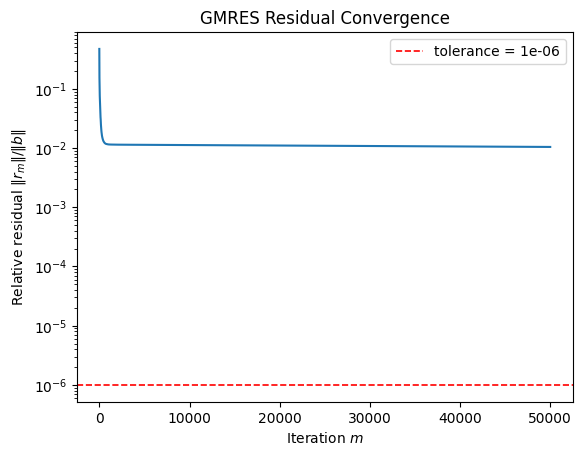

In [27]:
# Choose which run to inspect (0-based)
idx = 0

record = results[idx]
res = record["solver_result"]

print("Selected run")
print(f"  grid.shape      = {record['grid'].shape}")
print(f"  wavenumber k    = {record['wavenumber']}")
print(f"  load            = {getattr(record['load'], 'name', type(record['load']).__name__)}")
print(f"  discretisation  = {getattr(record['discretisation'], 'name', type(record['discretisation']).__name__)}")
print(f"  converged/info  = {res.converged} / {res.info}")
print(f"  iterations      = {len(res.residuals)}")

ax = plot_residuals(res, tol=opts.tol)
if ax is not None:
    ax.set_title("GMRES Residual Convergence")
    ax.set_xlabel("Iteration $m$")
    ax.set_ylabel(r"Relative residual $\|r_m\|/\|b\|$")
    plt.show()
else:
    print("Matplotlib not available; skipping plot.")


### Suggested follow-ups

- Extend `SweepConfig` with more grids, loads, or solvers.
- Attach a callback to log or save results as they stream.
- Convert the loop into a Pandas DataFrame for analysis.